# Customer Churn Prediction

## Exploratory Data Analysis (EDA)

### Objective

The purpose of this notebook is to explore the dataset and identify patterns, relationships, and factors associated with customer churn.

The insights obtained during this phase will guide feature engineering and model development.

In [73]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [74]:
#Load dataset
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

# Target Variable Analysis

Understanding the distribution of the target variable is essential before building predictive models.

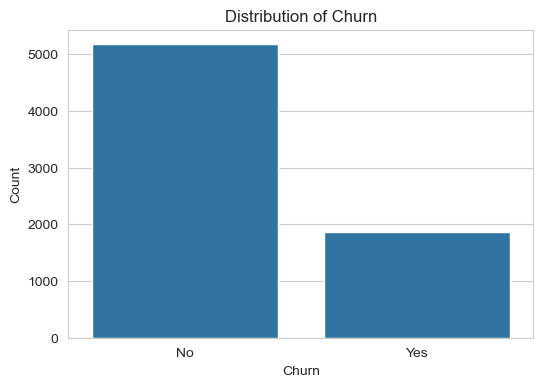

In [75]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

### Observation

The majority of customers did not churn.

The dataset exhibits a certain degree of class imbalance, which may influence model performance and evaluation.

# Numerical Features Analysis

This section explores the numerical variables and their distributions.

## Tenure distribution

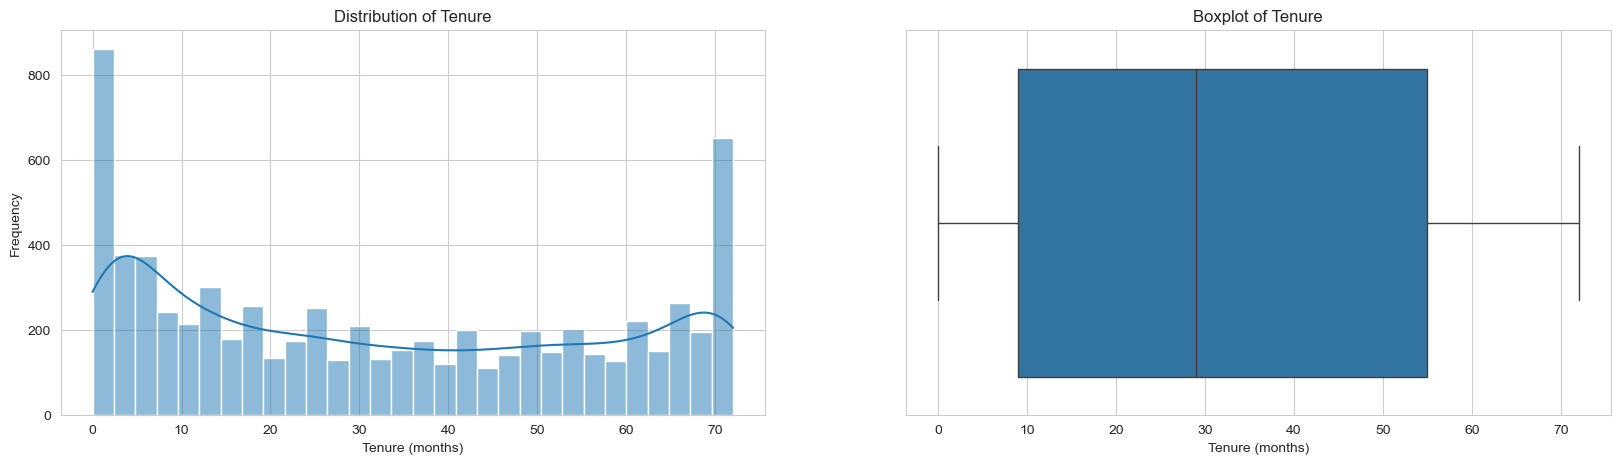

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(df["tenure"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Tenure")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df["tenure"], ax=axes[1])
axes[1].set_title("Boxplot of Tenure")
axes[1].set_xlabel("Tenure (months)")
plt.show()

### Observation

Customer tenure exhibits substantial variability.

A large number of customers are either relatively new or have remained with the company for a long period, suggesting the presence of both short-term and loyal customers.

## monthly charges distribution

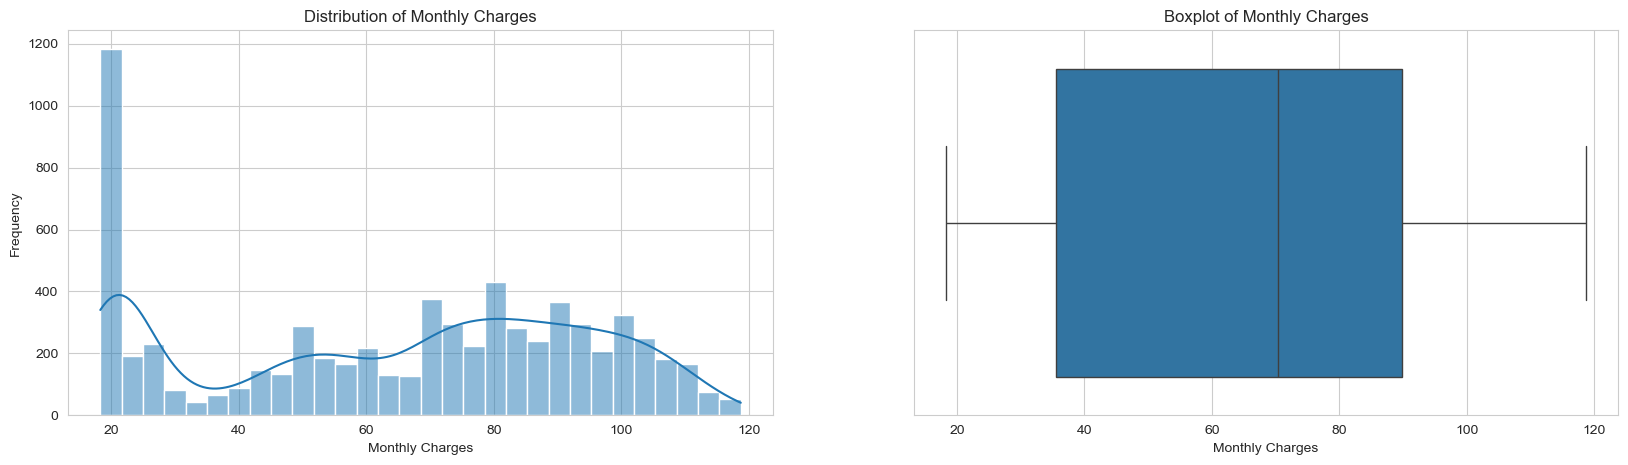

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Monthly Charges")
axes[0].set_xlabel("Monthly Charges")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Boxplot of Monthly Charges")
axes[1].set_xlabel("Monthly Charges")
plt.show()

### Observation

Monthly charges vary significantly among customers.

The distribution suggests the existence of multiple pricing plans, with certain charge ranges being more common than others.

## Total charges distribution

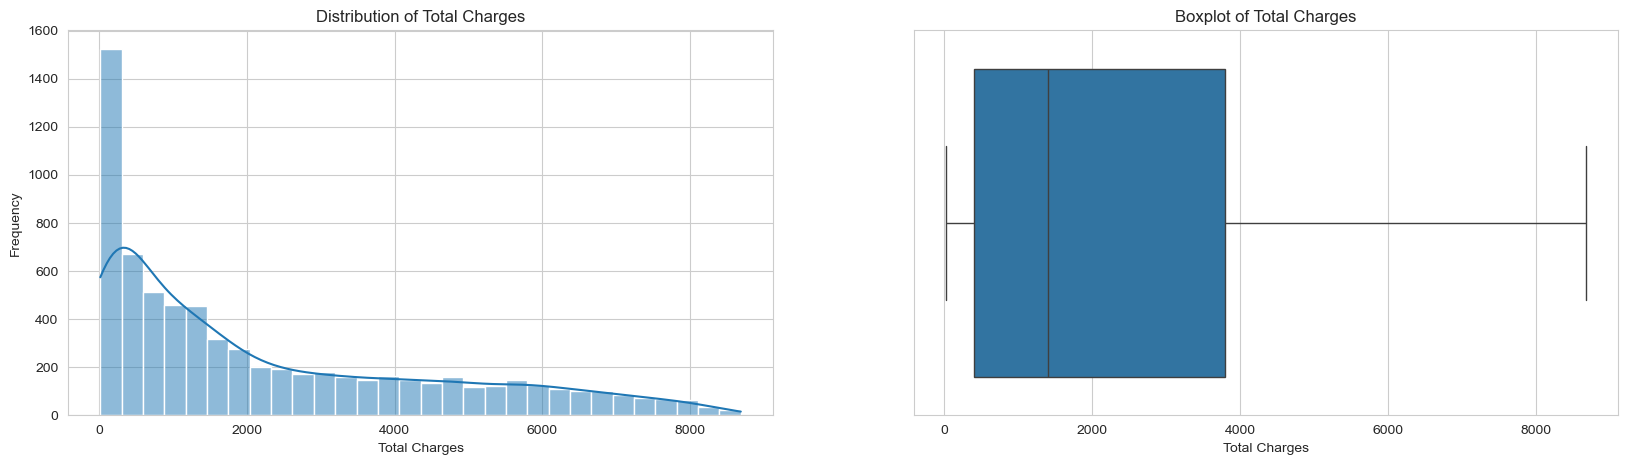

In [78]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(df["TotalCharges"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total Charges")
axes[0].set_xlabel("Total Charges")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df["TotalCharges"], ax=axes[1])
axes[1].set_title("Boxplot of Total Charges")
axes[1].set_xlabel("Total Charges")
plt.show()

### Observation

The distribution of total charges is right-skewed.

Customers who have remained with the company longer tend to accumulate higher total charges, while newer customers generally have lower total charges.

# Categorical Features Analysis

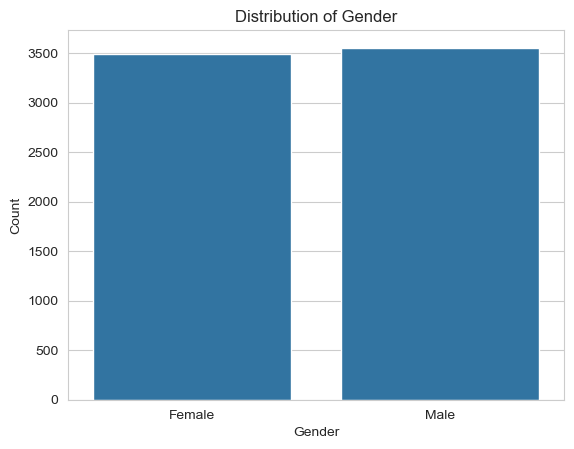

In [79]:
sns.countplot(data=df , x="gender")
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Observation

The dataset appears relatively balanced between male and female customers.

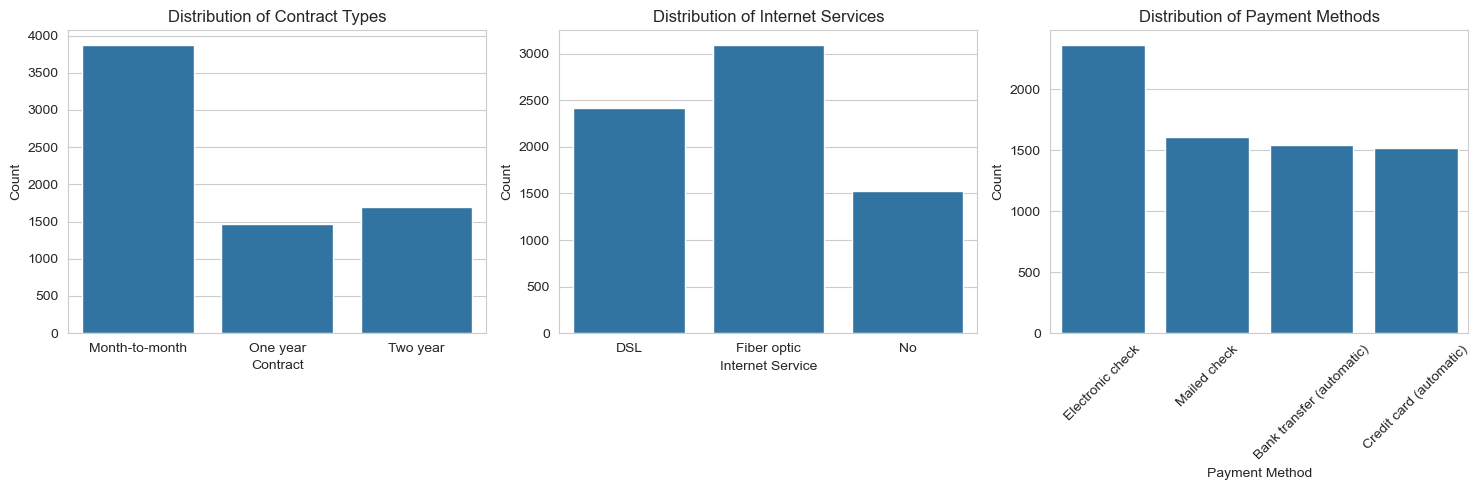

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x="Contract", data=df, ax=axes[0])
axes[0].set_title("Distribution of Contract Types")
axes[0].set_xlabel("Contract")
axes[0].set_ylabel("Count")

sns.countplot(x="InternetService", data=df, ax=axes[1])
axes[1].set_title("Distribution of Internet Services")
axes[1].set_xlabel("Internet Service")
axes[1].set_ylabel("Count")

sns.countplot(x="PaymentMethod", data=df, ax=axes[2])
axes[2].set_title("Distribution of Payment Methods")
axes[2].set_xlabel("Payment Method")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Relationship Between Features and Churn

## Tenure vs Churn

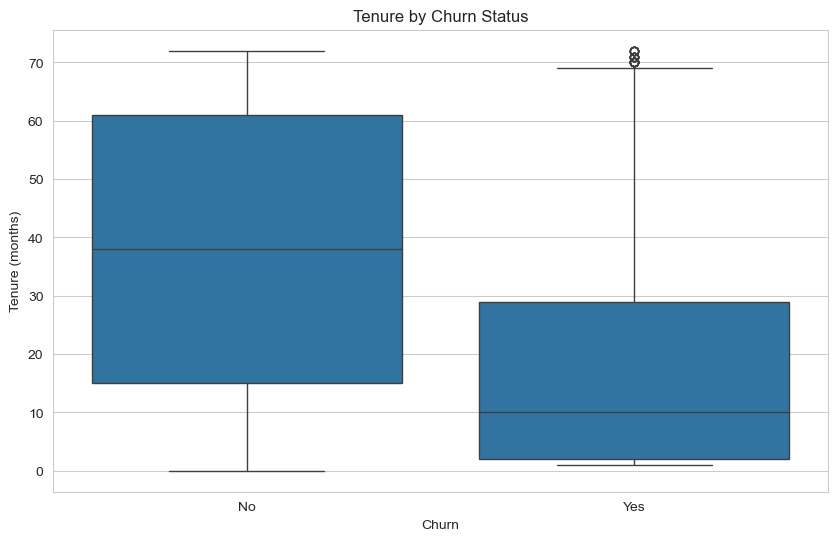

In [81]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

### Observation

Customers who churn generally have shorter tenure compared to customers who remain with the company.

This suggests that customer retention improves as customers stay with the company for longer periods.

## Monthly Charges vs Churn

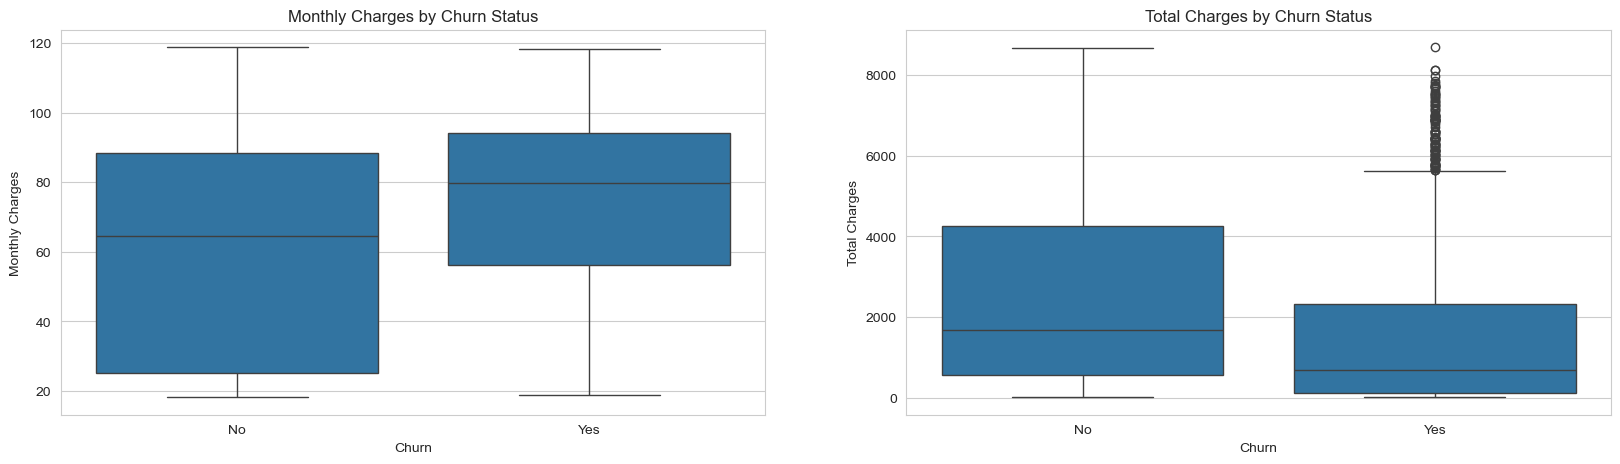

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[0])
axes[0].set_title("Monthly Charges by Churn Status")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Monthly Charges")

sns.boxplot(x="Churn", y="TotalCharges", data=df, ax=axes[1])
axes[1].set_title("Total Charges by Churn Status")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Total Charges")
plt.show()


### Observations 

* **Monthly Charges:** Customers who churned (**Yes**) generally have higher monthly expenses compared to those who stayed (**No**). The median monthly charge for churned customers is notably higher (around \$80 vs \$65), and the entire interquartile range (IQR) is shifted upward, indicating that higher monthly costs may be a driver of churn.
* **Total Charges:** Conversely, the total charges for churned customers are significantly lower, with a much tighter IQR and a median well below \$1,000. This suggests that customers who churn tend to do so early in their lifecycle (tenure is low), preventing them from accumulating high long-term total charges, despite their higher monthly rates. The numerous outliers in the churned group indicate a subset of long-term customers who also eventually left.

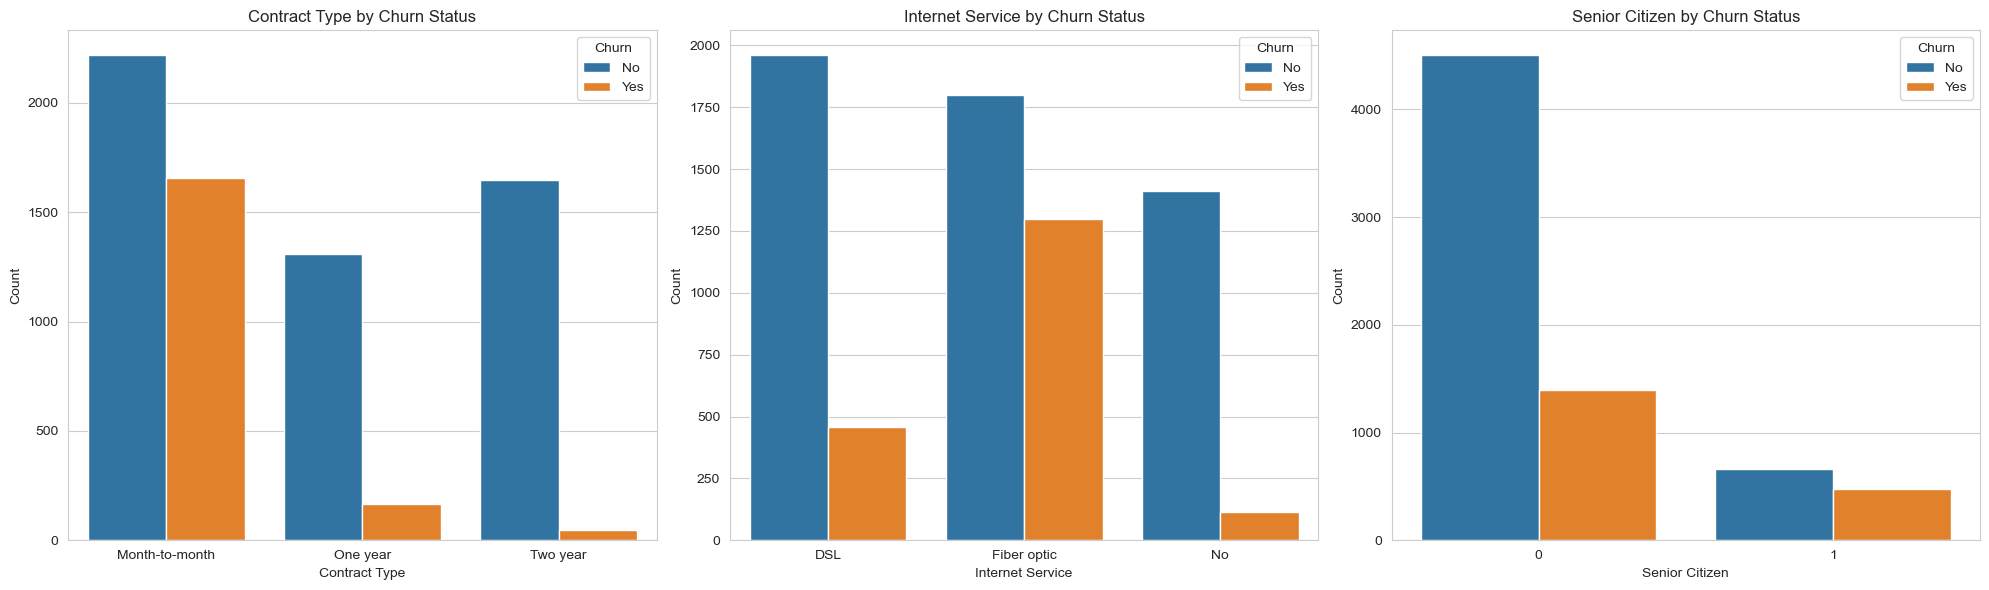

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(data=df , x="Contract", hue="Churn", ax=axes[0])
axes[0].set_title("Contract Type by Churn Status")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Count")

sns.countplot(data=df , x="InternetService", hue="Churn", ax=axes[1])
axes[1].set_title("Internet Service by Churn Status")
axes[1].set_xlabel("Internet Service")
axes[1].set_ylabel("Count")

sns.countplot(data=df , x="SeniorCitizen", hue="Churn", ax=axes[2])
axes[2].set_title("Senior Citizen by Churn Status")
axes[2].set_xlabel("Senior Citizen")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()


### Observations

As visualized in image_4aaee8.png, several categorical attributes show strong correlations with customer churn:

* **Contract Type:** Customers on **Month-to-month** contracts exhibit a drastically higher rate of churn compared to those on long-term commitments. Conversely, customers with **One year** or **Two year** contracts are highly stable, showing very low churn counts.

* **Internet Service:** Users with **Fiber optic** internet services experience a disproportionately high rate of churn, with the number of churned customers almost matching those who stayed. Meanwhile, **DSL** and **No internet service** groups show significantly higher retention rates. This suggests potential issues with fiber pricing, expectations, or service reliability.

* **Senior Citizen Status:** While **Senior Citizens** (represented as `1`) make up a smaller portion of the overall customer base, they have a visibly higher *proportional* churn rate compared to non-senior citizens (`0`), where the vast majority of customers remain retained.

# Correlation Analysis

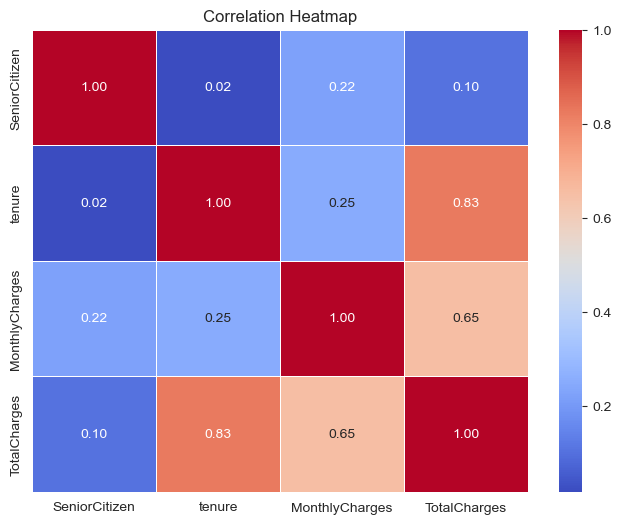

In [84]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Observation

The strongest correlation is observed between tenure and TotalCharges.

This relationship is expected, as customers who stay longer naturally accumulate higher total charges.

No extremely strong correlations are observed among the remaining numerical variables.

# Key Findings

The exploratory analysis revealed several important insights:

1. Customers who churn typically have shorter tenure.

2. Month-to-month contracts are strongly associated with higher churn rates.

3. Customers with higher monthly charges tend to churn more frequently.

4. Fiber Optic customers exhibit higher churn rates than other internet service groups.

5. Electronic Check users appear more likely to churn.

6. Tenure and TotalCharges show a strong positive correlation.

These findings suggest that contract type, tenure, monthly charges, and service characteristics are likely to be important predictors of customer churn.

In [85]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


# Conclusion

The exploratory data analysis identified several variables that appear strongly associated with customer churn.

The insights obtained from this analysis will guide feature engineering and machine learning model development in subsequent notebooks.

The next step is data preprocessing, including encoding categorical variables, handling missing values, scaling numerical features, and preparing the dataset for model training.